In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import subprocess
import struct

In [2]:
FONTSIZE=18
FIGSIZE=(8,8)

FIGURE_FOLDER = 'figures/'

In [3]:
N_per_period = 60
N_periods = 5
N = N_per_period*N_periods

In [4]:
methods = ['verlet_v', 'rkn4', 'fr_pv']

# Initial Conditions

In [5]:
x0, v0 = 10, 0.1

In [6]:
v0_vec = [0, v0]
x0_vec = [x0, 0]

# The Exact Orbit

Quantities Definining the Exact Orbit Expected

\begin{align}
    p &= (x_0 v_0)^2 &= 1.0 \\
    e &= \sqrt{1-p/a} &= 0.9 \\
    E_0 &= \frac{1}{2}v_0^2 - \frac{1}{x_0} &= -0.095 \\
    a &= \frac{-1}{2E_0} &= 5.263 \\
    \mathrm{Period} &= 2\pi a^{3/2} &= 75.866
\end{align}

In [7]:
energy_0 = 0.5*v0**2 - 1.0/x0;
a = -1.0/(2*energy_0);
p = (x0*v0)**2
ecc = np.sqrt(1-p/a)

period = 2*np.pi*a**(1.5);

In [8]:
t_end = period*N_periods
tstep = t_end/(N-1)

In [9]:
# Read the output file generated by our C code
def read_binary_file(filename):
    with open(filename, 'rb') as file:
        numSteps, numColumns = struct.unpack('ii', file.read(8))
        data = []
        # Read the input array (first "column")
        inputArray = np.fromfile(file, dtype=np.double, count=numSteps)
        data.append(inputArray)
        # Read each subsequent data array ("column")
        for _ in range(numColumns):
            dataArray = np.fromfile(file, dtype=np.double, count=numSteps)
            data.append(dataArray)
    return data

In [10]:
filenames = {}
labels    = {}
dat = {}
t,x,y,vx,vy = {},{},{},{},{}

In [11]:
for method in methods:
    label = method
    filename = 'out/test'

    result = subprocess.run(['./simulation',
                             '-v', '%f,%f' % tuple(v0_vec),
                             '-r', '%f,%f' % tuple(x0_vec), 
                             '-n', '%d'    % N,
                             '-b', '1',
                             '-s', '10',
                             '-t', '%f'    % tstep,
                             '-o', filename,
                             '-m', method])
    filenames[method] = filename
    labels[method]    = label
    #data = np.loadtxt(filename, delimiter='\t')
    data = read_binary_file(filename)
    dat[method] = data

for k in dat.keys():
    t[k], x[k], y[k], vx[k], vy[k] = dat[k]

-------------------------------------
Num steps set to 300
Using binary output mode.
Time step set to 1.268669
Using Velocity Verlet method.
Force mode set to: kepler
Output will be written to: out/test
Integrating from ti=0.0 to tf=380.6
Integrating.Writing output file...
Complete.
-------------------------------------
Num steps set to 300
Using binary output mode.
Time step set to 1.268669
Using RKN4 method.
Force mode set to: kepler
Output will be written to: out/test
Integrating from ti=0.0 to tf=380.6
Integrating.Writing output file...
Complete.
-------------------------------------
Num steps set to 300
Using binary output mode.
Time step set to 1.268669
Using Forrest-Ruth method.
Force mode set to: kepler
Output will be written to: out/test
Integrating from ti=0.0 to tf=380.6
Integrating.Writing output file...
Complete.


In [12]:
# Function to increase font size of "tick" labels
def bigTicks(size=FONTSIZE-4):
    plt.gca().tick_params(axis='both', which='major', labelsize=size)
    
def drawAxisLines():
    ax = plt.gca()
    ax.axhline(y=0, color='k', alpha=0.5, lw=1)
    ax.axvline(x=0, color='k', alpha=0.5, lw=1)
    
# Standardize the saving of plots
def savefig(savename, img_format='.svg'):
    plt.savefig(FIGURE_FOLDER + savename + img_format, bbox_inches='tight')

Text(0.5, 1.0, 'Algorithm Comparison')

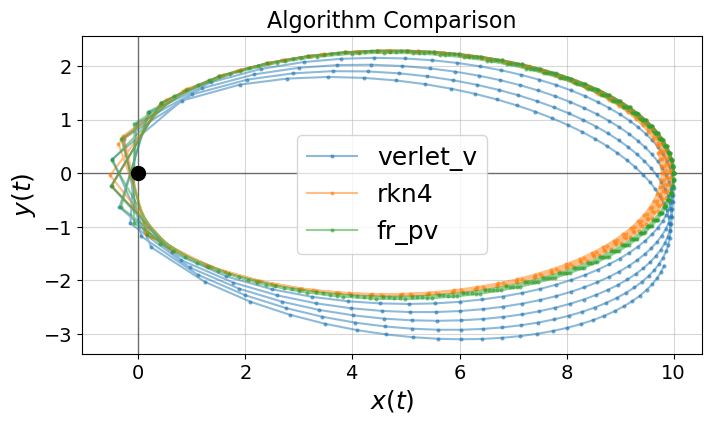

In [13]:
plt.figure(figsize=FIGSIZE)
drawAxisLines()

for k in dat.keys():
    plt.plot(x[k], y[k],'-o', label=labels[k], alpha=0.5, ms=2)

plt.plot([0], [0], 'o', ms=10, c='k')

plt.legend(fontsize=FONTSIZE)
plt.xlabel("$x(t)$", size=FONTSIZE)
plt.ylabel("$y(t)$", size=FONTSIZE)
plt.grid(alpha=0.5)
bigTicks()
plt.axis('scaled')

plt.title("Algorithm Comparison", size=16)

#savefig('orbits')